# Simulering og modellering

## Pseudotilfeldig tallgenerator

* Når man skal kjøre simuleringer på datamaskin trenger man ofte å bruke tilfeldige tall
* Vi trenger elementer av tilfeldighet i simuleringene våres for å beskrive prossesser vi ikke kan forklare analytisk/matematisk
* Dette gjelder både i ingeniørfagene, men spesielt når man skal modellere *mennesklig adferd*

![newton](https://pbs.twimg.com/media/D2EZ4DwVAAApNdd?format=jpg&name=900x900)

* Faktisk tilfeldighet er vanskelig å oppdrive på kommando
* På datamaskinen gjør vi «mattetriks» til å generere tall som ser tilsynelatende tilfeldige ut
* I python finner vi metoder vi kan bruke i `random`biblioteket

In [37]:
import random
tilfeldig_tall = random.random() #random() gir et "tilfeldig" flyttall mellom 0 og 1
print(f"Mitt tilfeldige tall er: {tilfeldig_tall:.3f}")

Mitt tilfeldige tall er: 0.397


* De tilfeldige tallene regnes ut -- de bruker da en såkalt «*seed*» til å begynne utregningen
* Default er systemklokken på dataen -- men vi kan gi vår egen med `random.seed(«tall»)`

In [69]:
random.seed(10)

In [74]:
tilfeldig_tall = random.random() #random() gir et "tilfeldig" flyttall mellom 0 og 1
print(f"Mitt tilfeldige tall er: {tilfeldig_tall:.3f}")

Mitt tilfeldige tall er: 0.813


* Dersom man kan trekke et tilfeldig tall mellom 0 og 1, har man egentlig alt man trenger

(array([ 25.,  60.,  89.,  99., 133., 176., 159.,  98.,  81.,  52.,  28.]),
 array([ 2.        ,  2.90909091,  3.81818182,  4.72727273,  5.63636364,
         6.54545455,  7.45454545,  8.36363636,  9.27272727, 10.18181818,
        11.09090909, 12.        ]),
 <BarContainer object of 11 artists>)

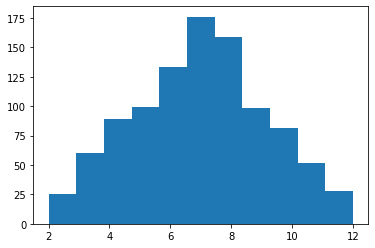

In [83]:
#EKs terningkast

import matplotlib.pyplot as plt

def kast_terning():
    return int(random.random()*6)+1

def kast_2_terning():
    return kast_terning()+kast_terning()

mange_kast = []
for i in range(1000):
    mange_kast.append(kast_2_terning())


plt.hist(mange_kast, bins=11)
plt.show()
    

In [108]:
# Trekk tilfeldig element fra liste
def trekk_tilfeldig(liste):
    n = len(liste)
    tilfeldig_indeks = int(random.random()*n)
    return(liste[tilfeldig_indeks])

print(trekk_tilfeldig(mange_kast))

9


* Av og til må man lage egne rutiner slik som dette
* Andre ganger kan vi bruke en av de mange innebygde funksjonene i `random` biblioteket
* [Dokumentasjon, random](https://docs.python.org/3/library/random.html)

In [150]:
frukt = ["Epler", "Pærer", "Mango", "Dragefrukt", "Fruktdrage"]
#Velg et utvalg av 10 frukter
fruktkurv = random.choices(frukt, k=10)
print(f"Fruktkurven inneholder: {fruktkurv}")

#Velg et tilfeldig heltall mellom 10 og 100
tilfeldig_heltall = random.randint(10,100)
print(f"Tenk på et tall mellom 10 og 100: {tilfeldig_heltall}")



Fruktkurven inneholder: ['Epler', 'Fruktdrage', 'Dragefrukt', 'Pærer', 'Fruktdrage', 'Pærer', 'Mango', 'Pærer', 'Mango', 'Mango']
Tenk på et tall mellom 10 og 100: 74


(array([   2.,    0.,    5.,   11.,   18.,   27.,   57.,  111.,  174.,
         294.,  422.,  580.,  680.,  833., 1064., 1052., 1000.,  913.,
         836.,  578.,  464.,  337.,  230.,  142.,   79.,   49.,   24.,
           9.,    5.,    4.]),
 array([-4.03027941, -3.77467488, -3.51907035, -3.26346583, -3.0078613 ,
        -2.75225677, -2.49665225, -2.24104772, -1.98544319, -1.72983867,
        -1.47423414, -1.21862961, -0.96302509, -0.70742056, -0.45181603,
        -0.19621151,  0.05939302,  0.31499755,  0.57060207,  0.8262066 ,
         1.08181113,  1.33741565,  1.59302018,  1.84862471,  2.10422923,
         2.35983376,  2.61543829,  2.87104281,  3.12664734,  3.38225187,
         3.6378564 ]),
 <BarContainer object of 30 artists>)

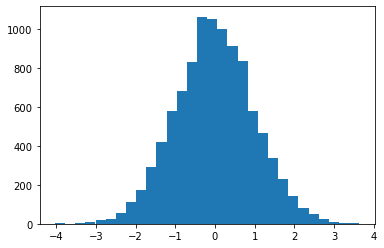

In [155]:
# Trekk et tilfeldig tall fra en normalfordeling:
normalfordeling = []
for i in range(10000):
    normalfordeling.append(random.gauss(mu=0, sigma=1))
    
plt.hist(normalfordeling, 30)


# Simulere med `While`
* Vi har blitt ganske godt kjent med `for`-løkken
* Den bruker vi når vi skal gjøre noe «for» alle elementene i en samling
* Vi vet altså på forhånd hvor mange ganger løkken skal iterere

* Dersom vi undersøker feks kundeadferd og bruker tilfeldige tall til å simulere avgjørelser vet man typisk ikke hvor mange ganger en løkke trenger å kjøre
* Da kan vi bruke `while` løkken



```python
while «boolsk uttrykk»:
    #Koded
    #Kode
    #Kode
```
* Løkken kjører så lenge det "boolske uttrykket" evalueres til `True`

* Dersom vi trenger å avbryte en løkke midt i en iterasjon kan vi bruke `break`
* Dersom vi trenger å starte løkken på nytt midt i en iterasjon kan vi bruke `continue`

In [180]:
fortsett = True
while fortsett:
    tilfeldig = round(random.random(),0) #Tilfeldig tall, 1 eller 0
    if tilfeldig == 0:
        print(f"tilfeldig = {tilfeldig}")
        continue
    else:
        print(f"tilfeldig = {tilfeldig}")
        break
    print("Dette blir aldri printet ut")

tilfeldig = 0.0
tilfeldig = 1.0


# EKS:
* Vi simulerer en kunde som handler
* Den fyller handlekurven med varer helt til budsjettet er tomt
* Eller kunden har fått det den trenger

* Vi sier at etter hver vare kunden handler, er det 10% sjanse for at den er ferdig å handle
* Kunden trekker en tilfeldig vare hver gang

In [248]:
varer = {"Epler": 10.0,
         "Pærer": 15.0,
         "Bleier": 35.0,
         "Sjokolade": 6.0,
         "Melk": 20.0,
         "Rundstykker": 13.0
        }

handlekurv = []
total_pris = 0.0
budsjett = 200

shopper = True
sluttsjanse = 0.1

while shopper:
    velg_vare = random.choice(list(varer.keys()))
    if total_pris+varer[velg_vare] > budsjett:
        shopper = False
    else:
        handlekurv.append(velg_vare)
        budsjett -= varer[velg_vare]
        total_pris += varer[velg_vare]

    #Sjekk om ferdig
    if random.random() < 0.1:
        shopper = False

print(f"""Kunden har handlet {handlekurv}
Det koster total kr. {total_pris:.2f}
Kunden har igjen {budsjett} kroner på budsjettet
""")
    

Kunden har handlet ['Pærer', 'Pærer']
Det koster total kr. 30.00
Kunden har igjen 170.0 kroner på budsjettet

